# Évaluation

**Objectif** : Construire un classifieur pour prédire si un client va quitter la banque (Exited = 1) ou non (Exited = 0).

## 1. Imports des données

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv('Data/Churn_Modelling.csv', sep=';')
df_scoring = pd.read_csv('Data/Churn_Modelling_scoring.csv', sep=';')

print(f"Données d'entraînement : {df.shape}")
print(f"Données de scoring : {df_scoring.shape}")
df.head()

Données d'entraînement : (6400, 13)
Données de scoring : (3600, 12)


,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
1,10,15661507,587,Spain,Male,45,6,0.00,1,0,0,158684.81,0
2,13,15625047,846,France,Female,38,5,0.00,1,1,1,187616.16,0
3,16,15728693,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0
4,18,15706552,533,France,Male,36,7,85311.70,1,0,1,156731.91,0


## 2. Exploration des données

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        6400 non-null   int64  
 1   CustomerId       6400 non-null   int64  
 2   CreditScore      6400 non-null   int64  
 3   Geography        6400 non-null   object 
 4   Gender           6400 non-null   object 
 5   Age              6400 non-null   int64  
 6   Tenure           6400 non-null   int64  
 7   Balance          6400 non-null   float64
 8   NumOfProducts    6400 non-null   int64  
 9   HasCrCard        6400 non-null   int64  
 10  IsActiveMember   6400 non-null   int64  
 11  EstimatedSalary  6400 non-null   float64
 12  Exited           6400 non-null   int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 650.1+ KB


In [55]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,6400.000000,6.400000e+03,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,3200.500000,1.569080e+07,650.565625,38.896563,4.978594,77123.206328,1.530781,0.712656,0.511406,99817.678031,0.218906
std,1847.665193,7.169499e+04,96.427468,10.436238,2.895429,62187.613515,0.587138,0.452559,0.499909,57607.032429,0.413537
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1600.750000,1.562865e+07,585.000000,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,50128.262500,0.000000
50%,3200.500000,1.569071e+07,652.000000,37.000000,5.000000,97682.815000,1.000000,1.000000,1.000000,100350.530000,0.000000
75%,4800.250000,1.575246e+07,717.000000,44.000000,7.000000,127828.327500,2.000000,1.000000,1.000000,149340.990000,0.000000
max,6400.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199970.740000,1.000000


In [56]:
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
RowNumber          0
CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Distribution de la variable cible (Exited) :
Exited
0    4999
1    1401
Name: count, dtype: int64

Taux de churn : 21.89%


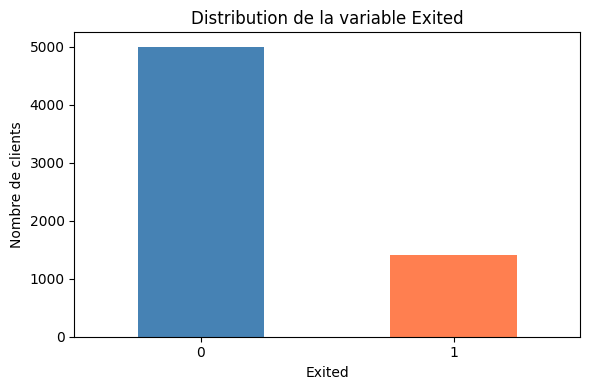

In [57]:
print("Distribution de la variable cible (Exited) :")
print(df['Exited'].value_counts())
print(f"\nTaux de churn : {df['Exited'].mean():.2%}")

plt.figure(figsize=(6, 4))
df['Exited'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribution de la variable Exited')
plt.xlabel('Exited')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

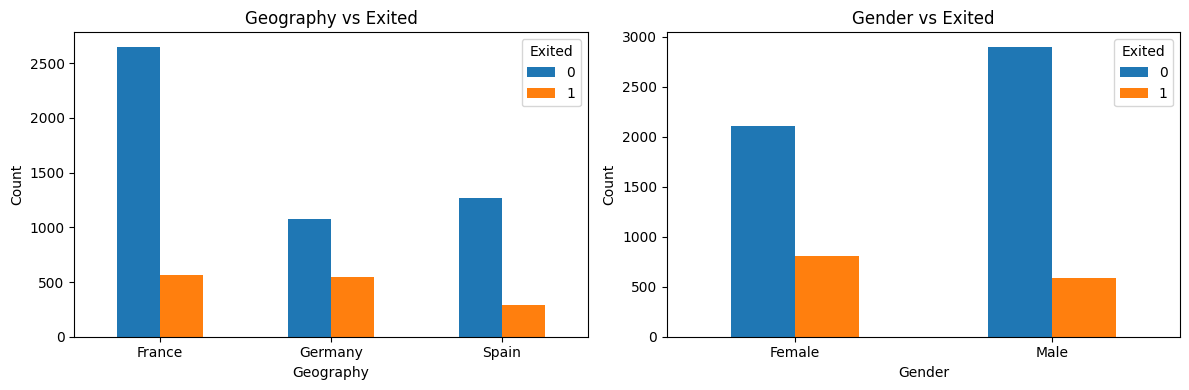

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['Geography', 'Gender']):
    pd.crosstab(df[col], df['Exited']).plot(kind='bar', ax=ax)
    ax.set_title(f'{col} vs Exited')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

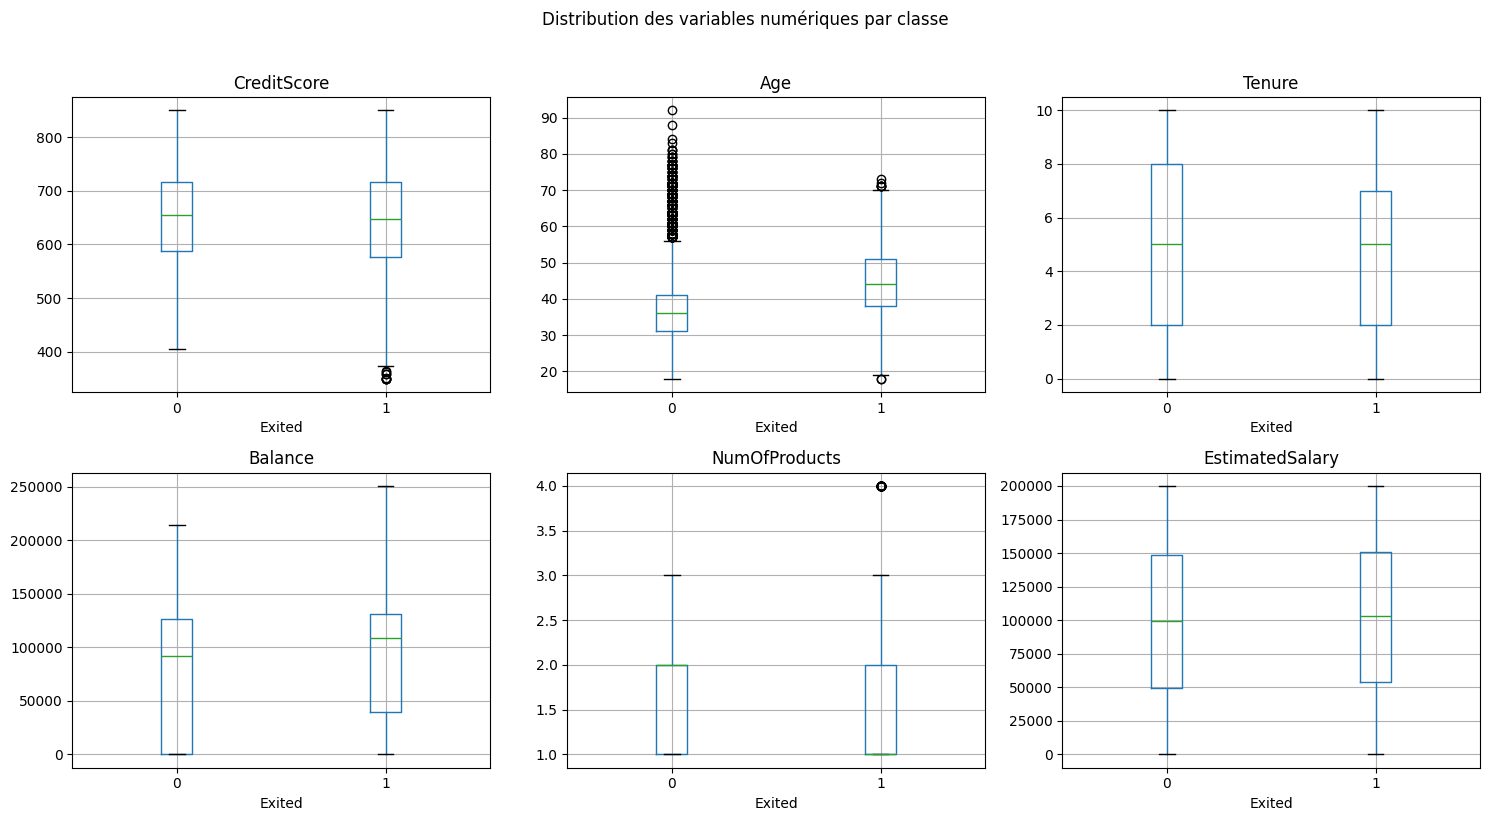

In [59]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    df.boxplot(column=col, by='Exited', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Exited')

plt.suptitle('Distribution des variables numériques par classe', y=1.02)
plt.tight_layout()
plt.show()

## 3. Préparation des données

In [60]:
def prepare_features(df):
    data = df.copy()
    
    cols_to_drop = ['RowNumber', 'CustomerId']
    data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
    
    data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)
    
    return data

df_prepared = prepare_features(df)

X = df_prepared.drop(columns=['Exited'])
y = df_prepared['Exited']

print(f"Features : {X.shape}")
print(f"Colonnes : {list(X.columns)}")

Features : (6400, 11)
Colonnes : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [61]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape}, Val : {X_val.shape}")
print(f"Distribution train : {y_train.value_counts().to_dict()}")
print(f"Distribution val : {y_val.value_counts().to_dict()}")

Train : (5120, 11), Val : (1280, 11)
Distribution train : {0: 3999, 1: 1121}
Distribution val : {0: 1000, 1: 280}


In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## 4. Définition de la métrique personnalisée

La métrique à optimiser est : `0.5 * Précision(classe 0) + 0.5 * Précision(classe 1)`

In [63]:
from sklearn.metrics import make_scorer

def custom_score(y_true, y_pred):
    prec_0 = precision_score(y_true, y_pred, pos_label=0)
    prec_1 = precision_score(y_true, y_pred, pos_label=1)
    return 0.5 * prec_0 + 0.5 * prec_1

custom_scorer = make_scorer(custom_score)

## 5. Entraînement et comparaison de modèles

In [64]:
def evaluate_model(name, model, X_tr, X_v, y_tr, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    
    score = custom_score(y_v, y_pred)
    prec_0 = precision_score(y_v, y_pred, pos_label=0)
    prec_1 = precision_score(y_v, y_pred, pos_label=1)
    
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Précision classe 0 : {prec_0:.4f}")
    print(f"Précision classe 1 : {prec_1:.4f}")
    print(f"Score custom       : {score:.4f}")
    print(f"\n{classification_report(y_v, y_pred)}")
    
    return score, model

In [65]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
score_lr, model_lr = evaluate_model("Régression Logistique", lr, X_train_scaled, X_val_scaled, y_train, y_val)


Régression Logistique
Précision classe 0 : 0.8900
Précision classe 1 : 0.4000
Score custom       : 0.6450

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1000
           1       0.40      0.69      0.51       280

    accuracy                           0.71      1280
   macro avg       0.65      0.70      0.65      1280
weighted avg       0.78      0.71      0.73      1280



In [66]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
score_rf, model_rf = evaluate_model("Random Forest", rf, X_train, X_val, y_train, y_val)


Random Forest
Précision classe 0 : 0.8997
Précision classe 1 : 0.6768
Score custom       : 0.7883

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1000
           1       0.68      0.64      0.66       280

    accuracy                           0.85      1280
   macro avg       0.79      0.78      0.78      1280
weighted avg       0.85      0.85      0.85      1280



In [67]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
score_gb, model_gb = evaluate_model("Gradient Boosting", gb, X_train, X_val, y_train, y_val)


Gradient Boosting
Précision classe 0 : 0.8749
Précision classe 1 : 0.7730
Score custom       : 0.8239

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1000
           1       0.77      0.51      0.62       280

    accuracy                           0.86      1280
   macro avg       0.82      0.73      0.76      1280
weighted avg       0.85      0.86      0.85      1280



In [68]:
results = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'Gradient Boosting'],
    'Score Custom': [score_lr, score_rf, score_gb]
}).sort_values('Score Custom', ascending=False)

print("\nRécapitulatif des scores :")
print(results.to_string(index=False))


Récapitulatif des scores :
               Modèle  Score Custom
    Gradient Boosting      0.823929
        Random Forest      0.788256
Régression Logistique      0.645000


## 6. Optimisation du meilleur modèle avec GridSearchCV

In [69]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring=custom_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score CV : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}
Meilleur score CV : 0.8305


In [70]:
best_model = grid_search.best_estimator_
score_best, _ = evaluate_model("Gradient Boosting", best_model, X_train, X_val, y_train, y_val)


Gradient Boosting
Précision classe 0 : 0.8617
Précision classe 1 : 0.8158
Score custom       : 0.8387

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1000
           1       0.82      0.44      0.57       280

    accuracy                           0.86      1280
   macro avg       0.84      0.71      0.74      1280
weighted avg       0.85      0.86      0.84      1280



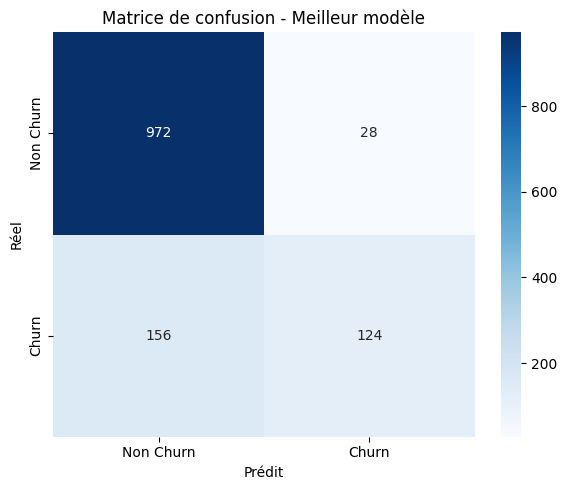

In [71]:
y_val_pred = best_model.predict(X_val)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Churn', 'Churn'], yticklabels=['Non Churn', 'Churn'])
plt.title('Matrice de confusion - Meilleur modèle')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

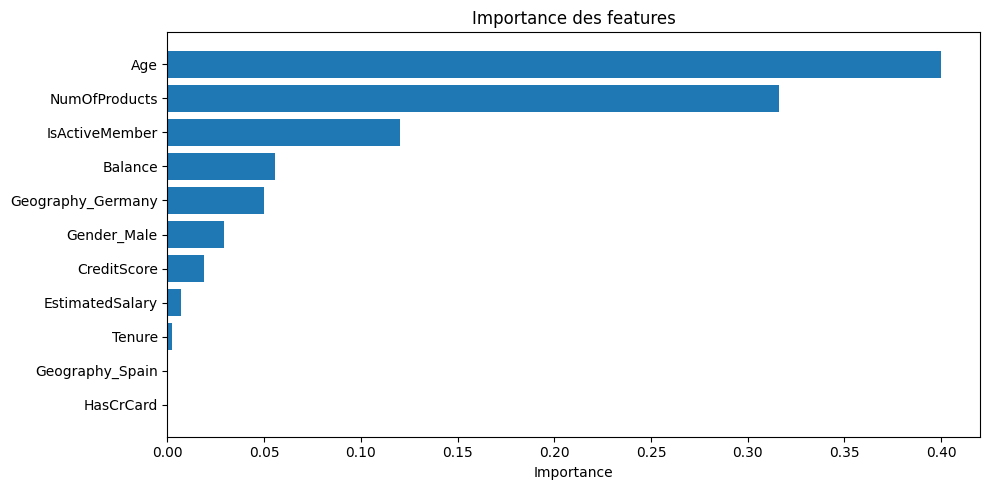

          Feature  Importance
              Age    0.400143
    NumOfProducts    0.316167
   IsActiveMember    0.120271
          Balance    0.055763
Geography_Germany    0.049983
      Gender_Male    0.029200
      CreditScore    0.018638
  EstimatedSalary    0.006980
           Tenure    0.002450
  Geography_Spain    0.000406
        HasCrCard    0.000000


In [72]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Importance des features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

## 7. Réentraînement sur toutes les données et prédiction sur le scoring

In [73]:
final_model = GradientBoostingClassifier(**grid_search.best_params_, random_state=42)
final_model.fit(X, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [74]:
scoring_ids = df_scoring['CustomerId']
df_scoring_prepared = prepare_features(df_scoring)

print(f"Colonnes entraînement : {list(X.columns)}")
print(f"Colonnes scoring      : {list(df_scoring_prepared.columns)}")

df_scoring_prepared = df_scoring_prepared[X.columns]

Colonnes entraînement : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
Colonnes scoring      : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [75]:
predictions = final_model.predict(df_scoring_prepared)

print(f"Nombre de prédictions : {len(predictions)}")
print(f"Distribution des prédictions :")
print(pd.Series(predictions).value_counts())

Nombre de prédictions : 3600
Distribution des prédictions :
0    3209
1     391
Name: count, dtype: int64


In [76]:
X_scoring = pd.DataFrame({
    'CustomerID': scoring_ids,
    'classe': predictions
})

X_scoring.to_csv('Churn_scoring_predictions.csv', index=False, columns=['CustomerID', 'classe'])

print("Fichier 'Churn_scoring_predictions.csv' créé avec succès.")
print(f"\nAperçu :")
X_scoring.head(10)

Fichier 'Churn_scoring_predictions.csv' créé avec succès.

Aperçu :


,CustomerID,classe
0,15647311,0
1,15592531,0
2,15656148,1
3,15592389,0
4,15737173,0
5,15737452,1
6,15568982,0
7,15699309,0
8,15725737,0
9,15736816,0
